# Locality experiment analysis

This notebook tests whether the configured SORBES trajectory count and walker depth provide enough local candidate quantity and sequence locality across starting peptides. Counts use the complete post-cap pool; the configured Levenshtein constraint is applied retrospectively as cumulative radii 1–8.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from pep_compass.analysis import ExperimentAnalysis
from pep_compass.analysis.reader import ExperimentReader


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate pyproject.toml')


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
RESULTS_PATH = REPOSITORY_ROOT / 'results' / 'locality_test'
TRAJECTORY_COUNTS = [1, 2, 5, 10, 20, 30, 50, 75, 100]
LEVENSTEIN_RADII = list(range(1, 9))
BOOTSTRAP_REPETITIONS = 300
CONFIDENCE = 0.95
RANDOM_SEED = 972
CHUNK_SIZE = 100_000
SKETCH_PRECISION = 12

## Load and validate experiment outputs

The reader discovers runs from manifests without loading candidate tables. The catalog is the experimental unit map used to compare starting peptide, method, and threshold.

In [2]:
reader = ExperimentReader(RESULTS_PATH)
selection = reader.select()
analysis = ExperimentAnalysis(selection, plot_theme='notebook', use_cache=True)

run_catalog = pd.DataFrame([run.metadata for run in reader.runs])
display(run_catalog[['experiment', 'grid_id', 'run_id', 'name', 'method', 'mutation.token_threshold']])

required_tables = ['optimizer_iterations', 'walker_steps', 'unique_candidates', 'candidate_occurrences']
availability = pd.DataFrame({
    'table': required_tables,
    'available_run_count': [len(selection.paths(table)) for table in required_tables],
})
display(availability)
if (availability['available_run_count'] == 0).any():
    raise RuntimeError('Normalized tracker-v2 outputs are required.')

,experiment,grid_id,run_id,name,method,mutation.token_threshold
0,01_sorbes_mutang_raw_pool,grid_0000,task_000000,middle-1,random_mutang,1.000000e-07
1,01_sorbes_mutang_raw_pool,grid_0000,task_000001,jurand-4,random_mutang,1.000000e-07
2,01_sorbes_mutang_raw_pool,grid_0001,task_000002,middle-1,random_mutang,1.000000e-06
3,01_sorbes_mutang_raw_pool,grid_0001,task_000003,jurand-4,random_mutang,1.000000e-06
4,01_sorbes_mutang_raw_pool,grid_0002,task_000004,middle-1,random_mutang,1.000000e-05
5,01_sorbes_mutang_raw_pool,grid_0002,task_000005,jurand-4,random_mutang,1.000000e-05


,table,available_run_count
0,optimizer_iterations,6
1,walker_steps,6
2,unique_candidates,6
3,candidate_occurrences,6


## SORBES trajectory saturation

Complete trajectories are sampled without replacement. Each panel counts the union of unique post-cap candidates inside a cumulative Levenshtein radius; lines show the median and IQR across starting peptides.

[sorbes_locality:task_000000] Starting: 3,002,405 rows to process


/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["levenshtein_to_center"] = chunk[
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["step_id"] = chunk["step_id"].astype(int)
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality

[sorbes_locality:task_000000] batch=10 rows=1,000,000/3,002,405 (33.3%) rate=561,165 rows/s elapsed=00:00:02 ETA=00:00:04


/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["levenshtein_to_center"] = chunk[
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["step_id"] = chunk["step_id"].astype(int)
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality

[sorbes_locality:task_000000] batch=20 rows=2,000,000/3,002,405 (66.6%) rate=575,785 rows/s elapsed=00:00:03 ETA=00:00:02


...

[sorbes_locality:task_000005] batch=26 rows=2,573,796/2,573,796 (100.0%) rate=521,191 rows/s elapsed=00:00:05 ETA=00:00:00


/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["levenshtein_to_center"] = chunk[
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["step_id"] = chunk["step_id"].astype(int)
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality

,run_id,name,sequence,experiment,grid_id,method,mutation.token_threshold,levenshtein_radius,trajectory_count,available_trajectories,unique_candidates,subset_confidence_low,subset_confidence_high,marginal_unique_candidates,marginal_per_trajectory
0,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,1,10,26.511102,15.027533,35.150393,NaN,NaN
1,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,2,10,38.571914,28.096142,49.295449,12.060813,12.060813
2,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,5,10,57.742799,51.320165,63.489523,19.170885,6.390295
3,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,10,10,68.570779,68.570779,68.570779,10.827980,2.165596
4,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,1,10,248.072002,134.173783,356.034980,NaN,NaN
5,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,2,10,421.790211,298.626133,572.164927,173.718210,173.718210
6,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,5,10,838.916753,685.253653,967.975892,417.126541,139.042180
7,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,10,10,1255.059692,1255.059692,1255.059692,416.142939,83.228588
8,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,3,1,10,1288.123781,734.009055,1983.143703,NaN,NaN
9,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,3,2,10,2343.758795,1663.285846,3268.910132,1055.635014,1055.635014


analysis                                                trajectory_saturation
unit                                                              peptide run
radii_are_cumulative                                                     True
accepted_only                                                           False
cardinality_method                                                HyperLogLog
cardinality_relative_standard_error                                   0.01625
resampling                             trajectory subsets without replacement
Name: value, dtype: object

array([[<Axes: title={'center': 'Levenshtein ≤ 1'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 2'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 3'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 4'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>],
       [<Axes: title={'center': 'Levenshtein ≤ 5'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 6'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 7'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 8'}, xlabel='trajectory count', ylabel='Unique candidates (median and IQR)'>]

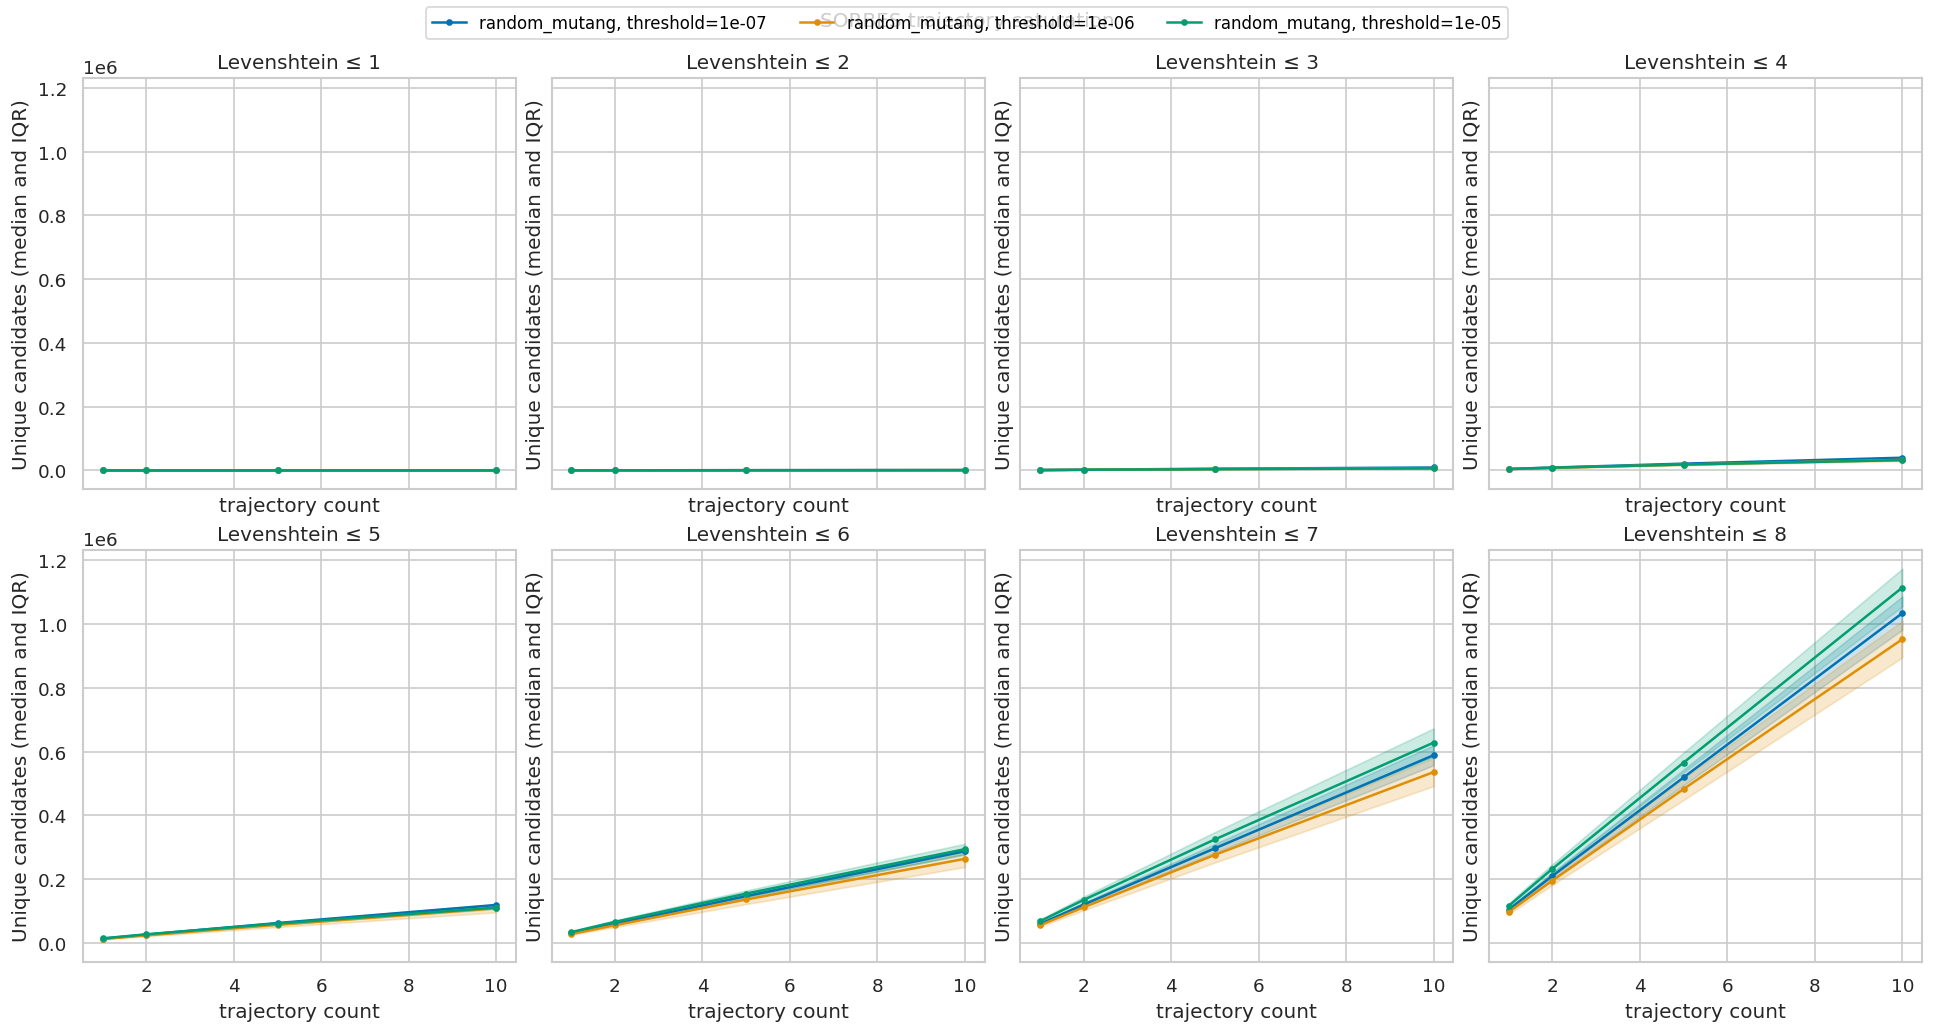

In [3]:
trajectory_result = analysis.locality.trajectory_saturation(
    trajectory_counts=TRAJECTORY_COUNTS,
    levenshtein_radii=LEVENSTEIN_RADII,
    repetitions=BOOTSTRAP_REPETITIONS,
    confidence=CONFIDENCE,
    random_seed=RANDOM_SEED,
    accepted_only=False,
    sketch_precision=SKETCH_PRECISION,
    chunk_size=CHUNK_SIZE,
)
display(trajectory_result.data.head(20))
display(pd.Series(trajectory_result.metadata, name='value'))
analysis.visualize.locality.trajectory_saturation(trajectory_result)

### Marginal trajectory yield

The marginal curve measures how many previously unseen candidates one additional trajectory contributes. A plateau here is the direct stopping criterion for the trajectory budget.

array([[<Axes: title={'center': 'Levenshtein ≤ 1'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 2'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 3'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 4'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>],
       [<Axes: title={'center': 'Levenshtein ≤ 5'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 6'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 7'}, xlabel='trajectory count', ylabel='New candidates per added trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 8'}, xlabel='trajectory count', ylabel='New candidates per added traje

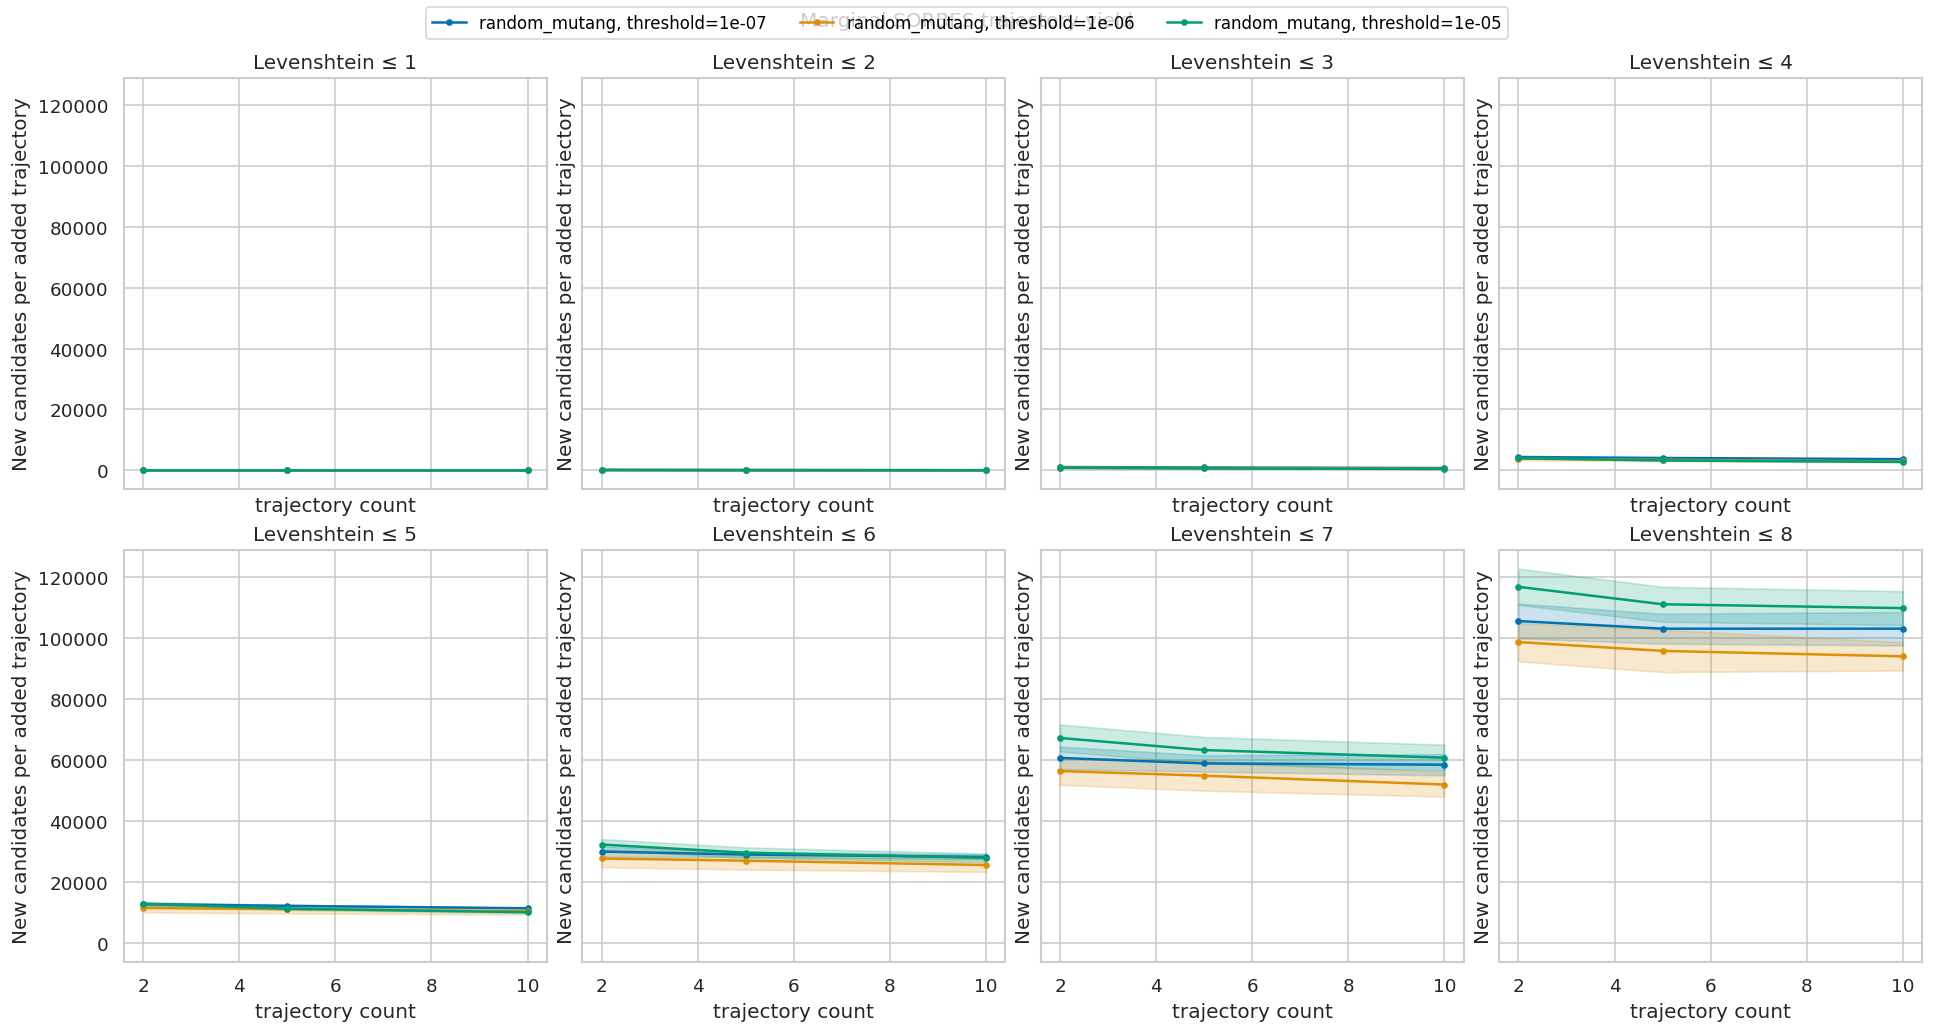

In [4]:
analysis.visualize.locality.trajectory_marginal(trajectory_result)

## SORBES step saturation

The central curve is the complete observed trajectory union, not a replacement bootstrap. The panels separate depth saturation from the selected sequence-locality radius.

[sorbes_locality:task_000000] Starting: 3,002,405 rows to process


/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["levenshtein_to_center"] = chunk[
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["step_id"] = chunk["step_id"].astype(int)
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality

[sorbes_locality:task_000000] batch=10 rows=1,000,000/3,002,405 (33.3%) rate=549,517 rows/s elapsed=00:00:02 ETA=00:00:04


/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["levenshtein_to_center"] = chunk[
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["step_id"] = chunk["step_id"].astype(int)
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality

[sorbes_locality:task_000000] batch=20 rows=2,000,000/3,002,405 (66.6%) rate=558,497 rows/s elapsed=00:00:04 ETA=00:00:02


...

[sorbes_locality:task_000005] batch=26 rows=2,573,796/2,573,796 (100.0%) rate=502,735 rows/s elapsed=00:00:05 ETA=00:00:00


/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["levenshtein_to_center"] = chunk[
/home/maxi7524/repositories/pep-compass/src/pep_compass/experiments/analysis/analysis_types/locality/sorbes.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["step_id"] = chunk["step_id"].astype(int)


,run_id,name,sequence,experiment,grid_id,method,mutation.token_threshold,levenshtein_radius,max_step,trajectory_count,active_trajectories,active_trajectory_fraction,unique_candidates,new_unique_candidates,new_candidates_per_active_trajectory,per_trajectory_candidates_median
0,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,1,10,10,1.0,48.283467,48.283467,4.828347,15.027533
1,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,2,10,10,1.0,60.443792,12.160326,1.216033,22.059418
2,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,3,10,10,1.0,66.537520,6.093728,0.609373,24.070712
3,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,4,10,10,1.0,66.537520,0.000000,0.000000,24.070712
4,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,5,10,10,1.0,68.570779,2.033259,0.203326,26.082994
5,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,6,10,10,1.0,68.570779,0.000000,0.000000,26.082994
6,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,7,10,10,1.0,68.570779,0.000000,0.000000,26.082994
7,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,8,10,10,1.0,68.570779,0.000000,0.000000,26.082994
8,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,9,10,10,1.0,68.570779,0.000000,0.000000,26.082994
9,task_000000,middle-1,FLYKWWIRIGRLKL,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,10,10,10,1.0,68.570779,0.000000,0.000000,26.082994


analysis                                                  step_saturation
unit                                                          peptide run
radii_are_cumulative                                                 True
accepted_only                                                       False
central_curve                          complete observed trajectory union
cardinality_method                                            HyperLogLog
cardinality_relative_standard_error                               0.01625
Name: value, dtype: object

array([[<Axes: title={'center': 'Levenshtein ≤ 1'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 2'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 3'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 4'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>],
       [<Axes: title={'center': 'Levenshtein ≤ 5'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 6'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 7'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>,
        <Axes: title={'center': 'Levenshtein ≤ 8'}, xlabel='max step', ylabel='Unique candidates (median and IQR)'>]],
      dtype=object)

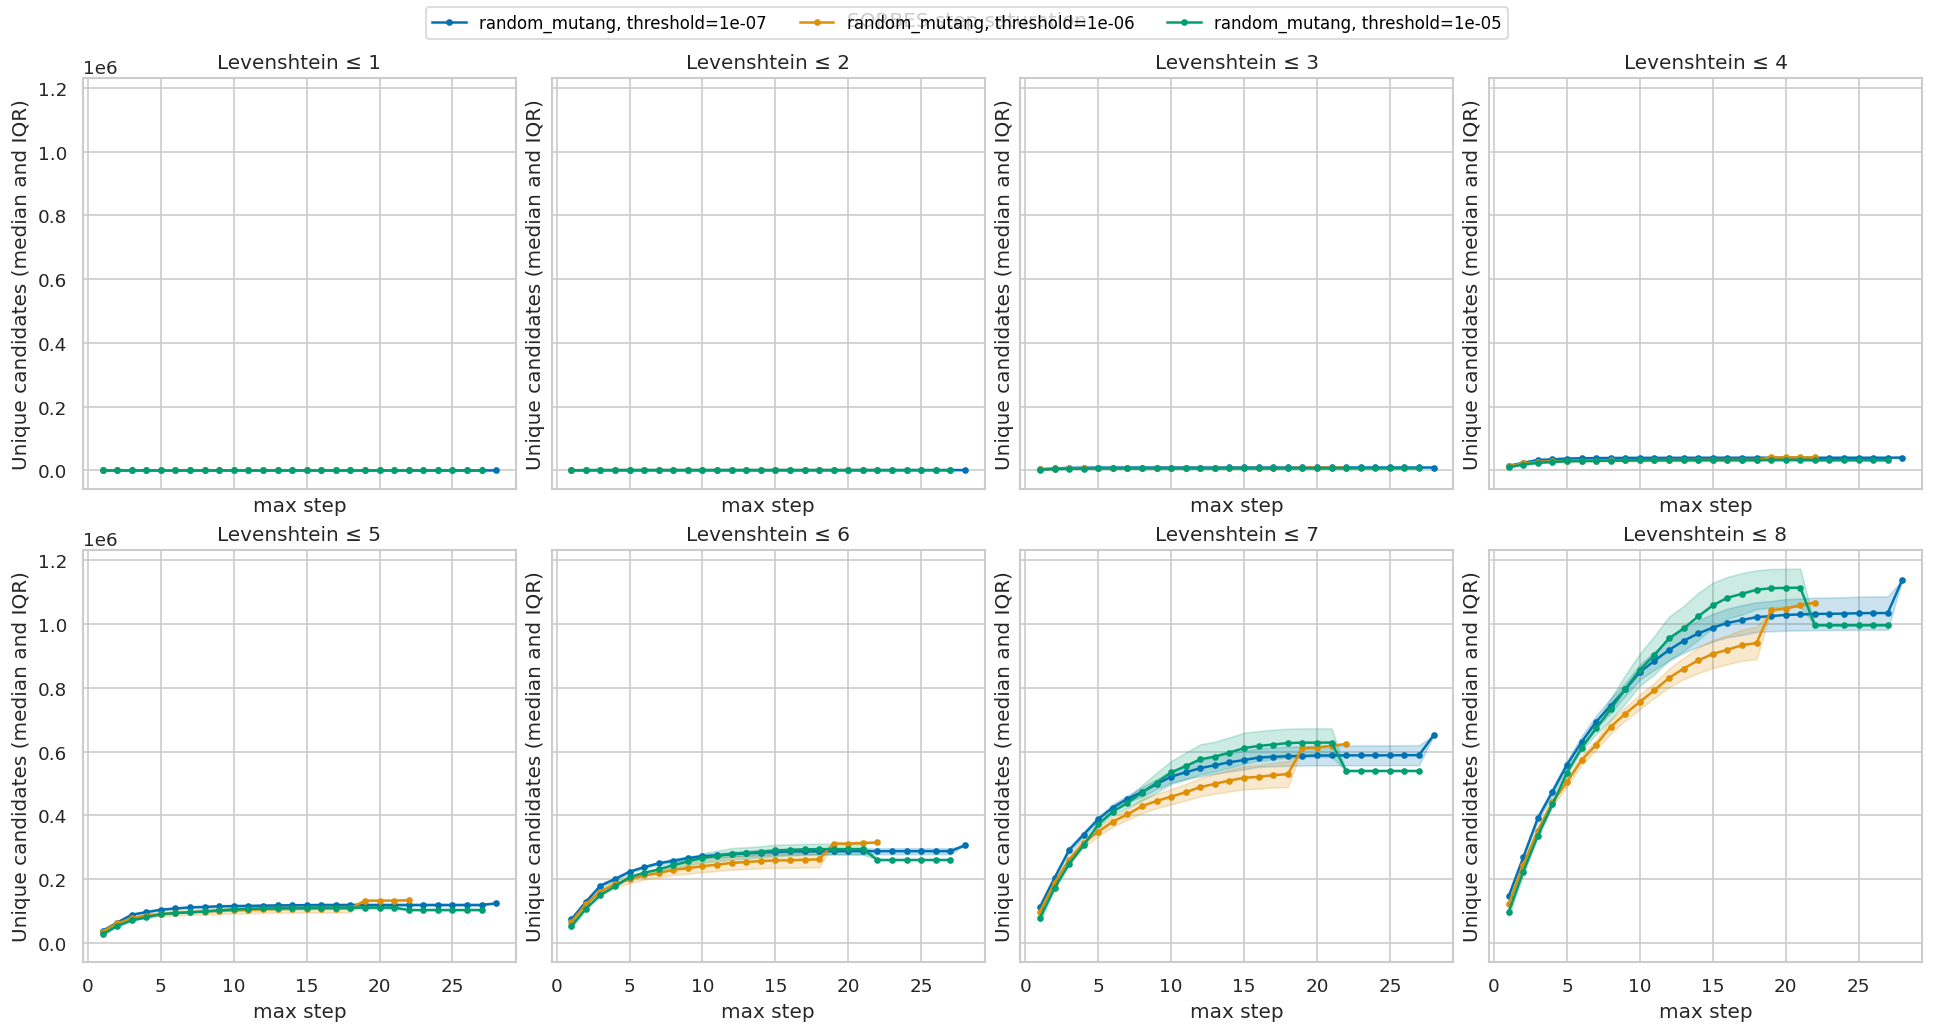

In [5]:
step_result = analysis.locality.step_saturation(
    levenshtein_radii=LEVENSTEIN_RADII,
    accepted_only=False,
    sketch_precision=SKETCH_PRECISION,
    chunk_size=CHUNK_SIZE,
)
display(step_result.data.head(20))
display(pd.Series(step_result.metadata, name='value'))
analysis.visualize.locality.step_saturation(step_result)

### Marginal step yield

New candidates are divided by the trajectories still active at that step. This distinguishes genuine local exhaustion from trajectories simply terminating at different depths.

array([[<Axes: title={'center': 'Levenshtein ≤ 1'}, xlabel='max step', ylabel='New candidates per active trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 2'}, xlabel='max step', ylabel='New candidates per active trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 3'}, xlabel='max step', ylabel='New candidates per active trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 4'}, xlabel='max step', ylabel='New candidates per active trajectory'>],
       [<Axes: title={'center': 'Levenshtein ≤ 5'}, xlabel='max step', ylabel='New candidates per active trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 6'}, xlabel='max step', ylabel='New candidates per active trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 7'}, xlabel='max step', ylabel='New candidates per active trajectory'>,
        <Axes: title={'center': 'Levenshtein ≤ 8'}, xlabel='max step', ylabel='New candidates per active trajectory'>]],
      dtype=object)

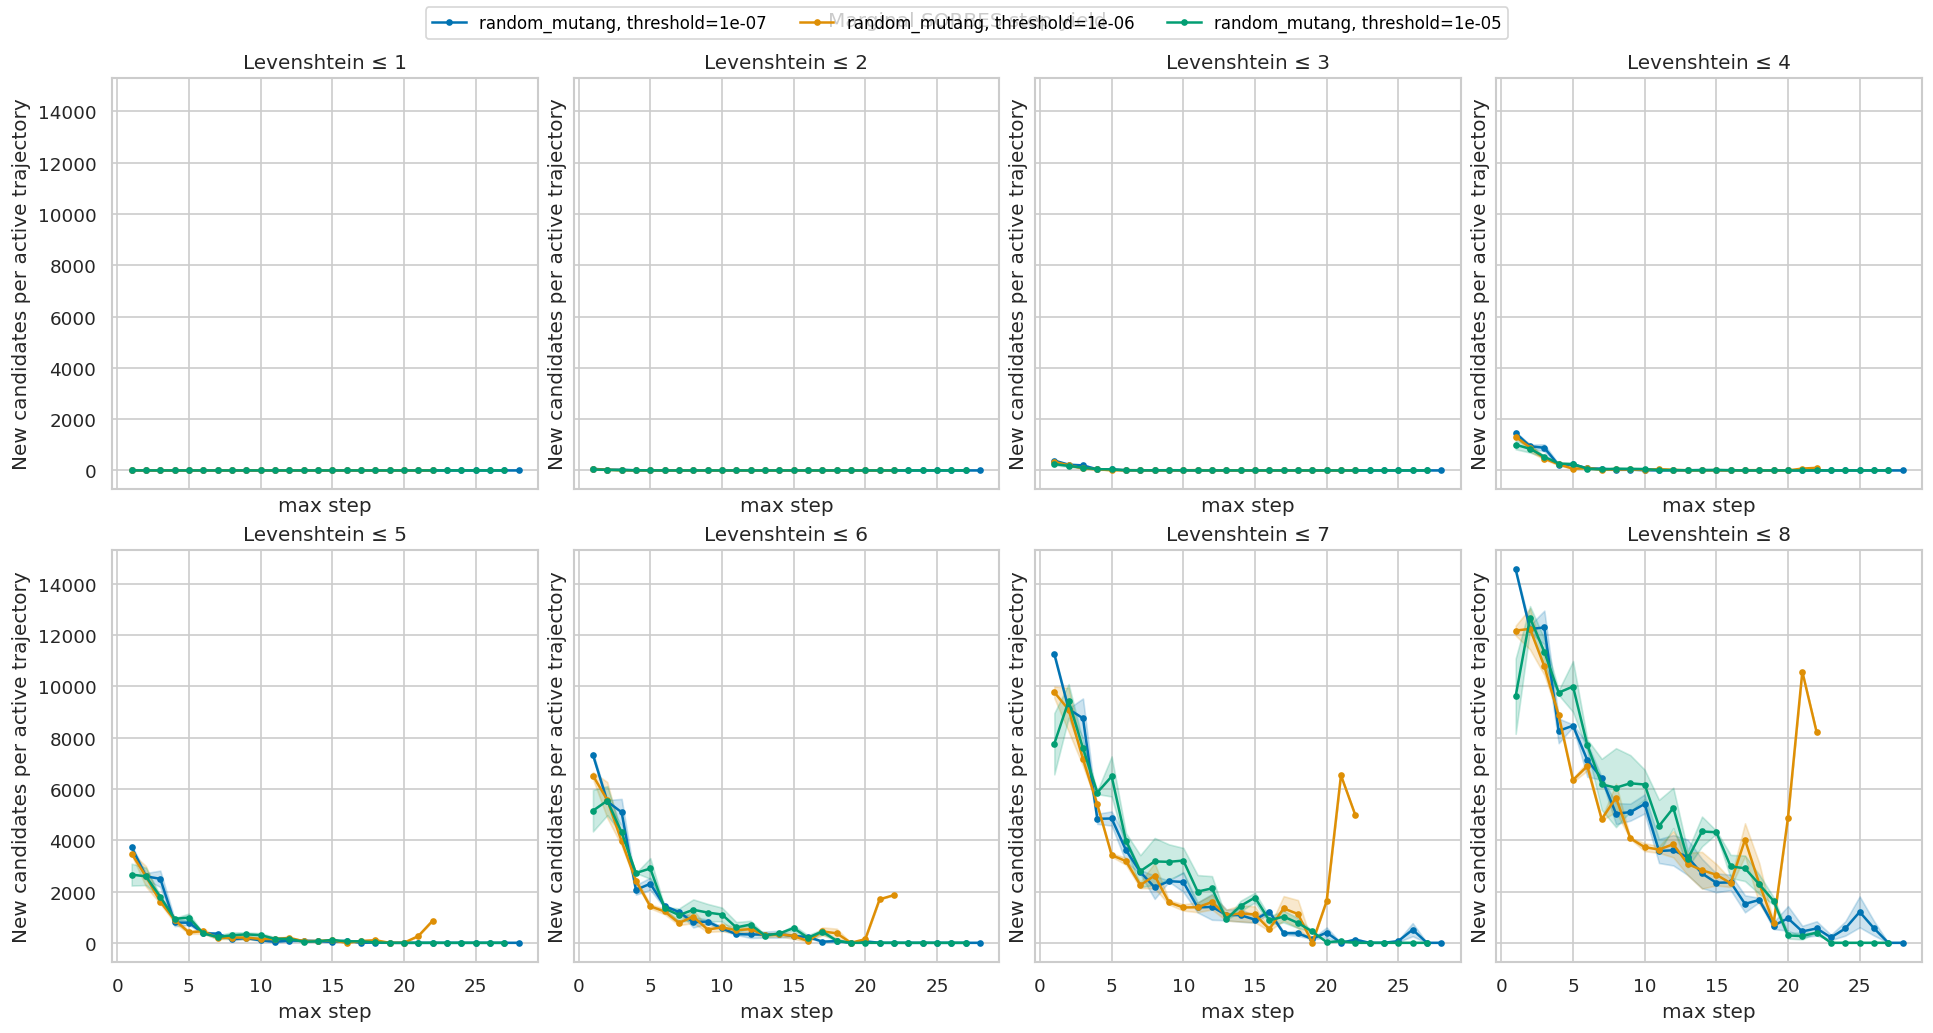

In [6]:
analysis.visualize.locality.step_marginal(step_result)

## Latent locality

A representative candidate sample compares candidate-to-walker distance, candidate-to-trajectory-origin distance, and walker drift from that origin. Together they separate local MUTANG spread from accumulated SORBES drift without requiring PoGS.

[latent_locality] Counting candidate occurrences...
[latent_locality] Starting: 16,941,305 rows to process
[latent_locality] Counting unique candidates per run...
[latent_locality] task_000000: 2,992,492 unique candidates
[latent_locality] task_000001: 3,002,373 unique candidates
[latent_locality] task_000002: 2,505,860 unique candidates
[latent_locality] task_000003: 2,671,487 unique candidates
[latent_locality] task_000004: 3,092,515 unique candidates
[latent_locality] task_000005: 2,450,244 unique candidates
[latent_locality] Candidate population: 16,714,971; planned sample: 50,000
[latent_locality] Preparing run 1/6 (task_000000): loading lookup tables
[latent_locality:candidate_sampling:task_000000] Starting: 2,992,492 rows to process
[latent_locality:candidate_sampling:task_000000] batch=1 rows=5,000/2,992,492 (0.2%) rate=71,191 rows/s elapsed=00:00:00 ETA=00:00:42
[latent_locality:candidate_sampling:task_000000] batch=2 rows=10,000/2,992,492 (0.3%) rate=75,700 rows/s elapsed=00:

,levenshtein_to_center,candidate_count,walker_candidate_distance_mean,walker_candidate_distance_median,walker_candidate_distance_q25,walker_candidate_distance_q75,origin_candidate_distance_mean,origin_candidate_distance_median,origin_candidate_distance_q25,origin_candidate_distance_q75,walker_origin_distance_mean,walker_origin_distance_median,walker_origin_distance_q25,walker_origin_distance_q75
0,1,2,1.542907,1.542907,1.493419,1.592396,1.109145,1.109145,0.975731,1.242559,1.137296,1.137296,1.012135,1.262457
1,2,7,1.457873,1.512300,1.166977,1.697206,1.242732,1.198358,1.068269,1.372143,0.614953,0.564766,0.000000,1.131430
2,3,135,1.931246,1.749150,1.568282,2.084554,1.770355,1.635449,1.428847,1.888864,0.664265,0.773139,0.000000,1.064230
3,4,505,2.277730,2.097582,1.852215,2.463605,2.127654,1.958721,1.724933,2.307677,0.773085,0.800005,0.000000,1.145858
4,5,1422,2.599273,2.379459,2.077255,2.891393,2.424007,2.216990,1.944199,2.606713,0.927886,0.888042,0.000000,1.407749
5,6,2989,2.918104,2.715015,2.360426,3.302751,2.703285,2.494738,2.197296,2.954996,1.188145,1.156528,0.770286,1.752943
6,7,5381,3.229014,3.063098,2.615330,3.698178,2.970479,2.774729,2.410145,3.322042,1.484268,1.510552,0.942277,2.104109
7,8,8100,3.515406,3.358071,2.885785,4.043958,3.224976,3.016302,2.621923,3.684152,1.766015,1.851311,1.273418,2.346095
8,9,9616,3.773605,3.648571,3.144576,4.325054,3.465973,3.286033,2.836239,4.005975,1.995801,2.072985,1.562099,2.493620
9,10,9486,3.969574,3.866240,3.374570,4.493866,3.648915,3.492794,3.038014,4.198955,2.184628,2.249675,1.815663,2.617489


analysis                                                          latent_locality
unique_per_run                                                               True
rows_scanned                                                             16941305
rows_analyzed                                                               50000
candidate_population_size                                                16714971
candidate_sample_size                                                       50000
candidate_sampling_fraction                                              0.002991
candidate_sampling                uniform_without_replacement_proportional_by_run
elapsed_seconds                                                        361.784052
quantiles_are_sampled                                                        True
quantile_sample_size_per_group                                              20000
spearman_sample_size                                                        20000
spearman_correla

<Axes: title={'center': 'Latent locality'}, ylabel='Euclidean latent distance'>

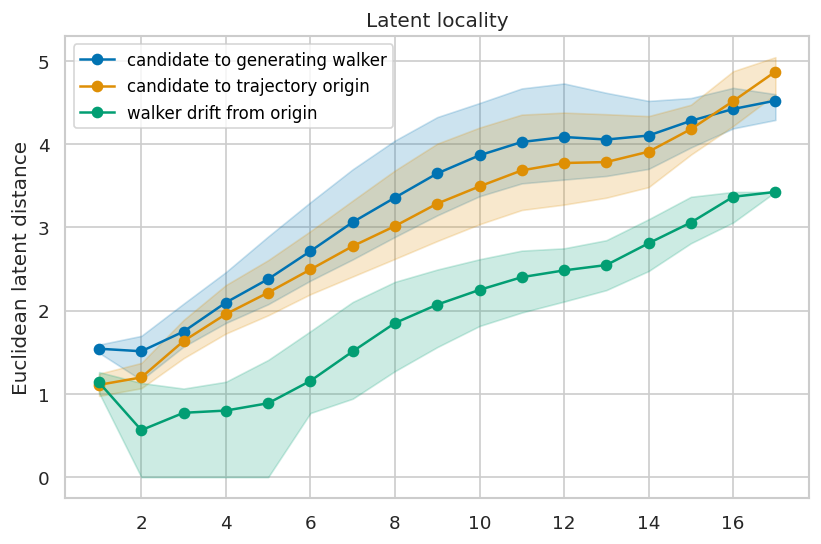

In [7]:
latent_result = analysis.locality.latent_locality(
    candidate_sample_size=50_000,
    candidate_scan_chunk_size=5_000,
    chunk_size=5_000,
    quantile_sample_size=20_000,
    diagnostic_sample_size=2_000,
    random_seed=RANDOM_SEED,
)
display(latent_result.data)
display(pd.Series(latent_result.metadata, name='value'))
analysis.visualize.locality.latent_locality(latent_result)

## Method comparison against random MUTANG

Each panel applies one cumulative Levenshtein radius retrospectively. Colored dots are loaded peptide sequences, method variants remain separate, and the black marker is the cross-peptide median.

[mutang_selectivity] Counting walker steps...
[mutang_selectivity] Starting: 1,033 rows to process
[mutang_selectivity] batch=1 rows=182/1,033 (17.6%) rate=6,073 rows/s elapsed=00:00:00 ETA=00:00:00
[mutang_selectivity] batch=2 rows=363/1,033 (35.1%) rate=6,547 rows/s elapsed=00:00:00 ETA=00:00:00
[mutang_selectivity] batch=3 rows=518/1,033 (50.1%) rate=6,149 rows/s elapsed=00:00:00 ETA=00:00:00
[mutang_selectivity] batch=4 rows=682/1,033 (66.0%) rate=6,212 rows/s elapsed=00:00:00 ETA=00:00:00
[mutang_selectivity] batch=5 rows=873/1,033 (84.5%) rate=6,453 rows/s elapsed=00:00:00 ETA=00:00:00
[mutang_selectivity] batch=6 rows=1,033/1,033 (100.0%) rate=6,403 rows/s elapsed=00:00:00 ETA=00:00:00


,experiment,grid_id,method,mutation.token_threshold,step_count,effective_dimension_mean,mutation_positions_mean,residue_options_mean,theoretical_product_median,post_cap_unique_mean,post_constraint_unique_mean,cap_efficiency_mean,constraint_retention_mean
0,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,363,8.192837,13.132231,81.030303,3.194880e+09,16593.859504,255.939394,0.000261,0.014918
1,01_sorbes_mutang_raw_pool,grid_0001,random_mutang,1.000000e-06,319,7.855799,13.128527,69.253918,5.852529e+08,16371.789969,261.507837,0.001103,0.016647
2,01_sorbes_mutang_raw_pool,grid_0002,random_mutang,1.000000e-05,351,8.019943,12.270655,56.521368,3.265920e+07,16225.450142,273.207977,0.016480,0.016854


analysis                                                              mutang_selectivity
rows_scanned                                                                        1033
elapsed_seconds                                                                  0.17317
distribution_statistics_are_sampled                                                 True
distribution_sample_size                                                           50000
correlations                           {'effective_dimension': {'correlation': -0.030...
Name: value, dtype: object

<Axes: title={'center': 'MUTANG selectivity'}, xlabel='mutation.token_threshold', ylabel='Retained unique candidates'>

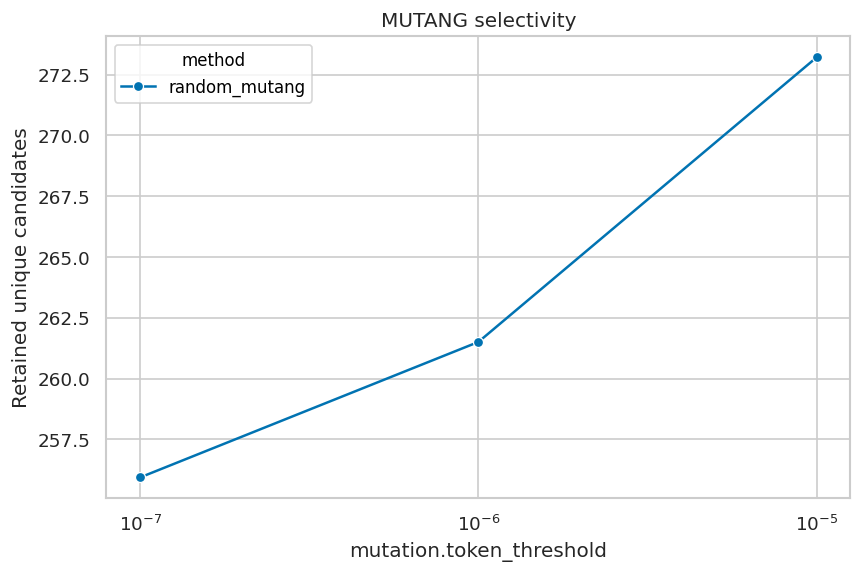

In [8]:
method_result = analysis.locality.method_comparison(
    levenshtein_radii=LEVENSTEIN_RADII,
    sketch_precision=SKETCH_PRECISION,
    chunk_size=CHUNK_SIZE,
)
display(method_result.data)
display(pd.Series(method_result.metadata, name='value'))
analysis.visualize.locality.method_comparison(method_result)
analysis.visualize.locality.method_retention(method_result)

## Preliminary parameter summary

Iteration-level yield, retention, and duplication provide a compact operational summary. It intentionally excludes PoGS and final parameter ranking at this stage.

[parameter_selection] Counting optimizer iterations...
[parameter_selection] Starting: 12 rows to process
[parameter_selection] batch=1 rows=2/12 (16.7%) rate=121 rows/s elapsed=00:00:00 ETA=00:00:00
[parameter_selection] batch=2 rows=4/12 (33.3%) rate=131 rows/s elapsed=00:00:00 ETA=00:00:00
[parameter_selection] batch=3 rows=6/12 (50.0%) rate=132 rows/s elapsed=00:00:00 ETA=00:00:00
[parameter_selection] batch=4 rows=8/12 (66.7%) rate=132 rows/s elapsed=00:00:00 ETA=00:00:00
[parameter_selection] batch=5 rows=10/12 (83.3%) rate=127 rows/s elapsed=00:00:00 ETA=00:00:00
[parameter_selection] batch=6 rows=12/12 (100.0%) rate=128 rows/s elapsed=00:00:00 ETA=00:00:00


,experiment,grid_id,method,mutation.token_threshold,run_count,unique_candidates_mean,candidates_per_trajectory_mean,candidates_per_step_mean,constraint_retention_mean,duplication_mean
0,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,19737.00,3947.40,217.489952,0.013169,0.004761
1,01_sorbes_mutang_raw_pool,grid_0001,random_mutang,1.000000e-06,2,16519.25,3303.85,205.992683,0.012684,0.008526
2,01_sorbes_mutang_raw_pool,grid_0002,random_mutang,1.000000e-05,2,16178.00,3235.60,186.105710,0.011858,0.028619


analysis                                         parameter_selection
rows_scanned                                                      12
elapsed_seconds                                             0.095896
status             preliminary; APEX and PoGS objectives are not ...
Name: value, dtype: object

<Axes: title={'center': 'Preliminary parameter selection'}, xlabel='Constraint retention', ylabel='Unique candidates per trajectory'>

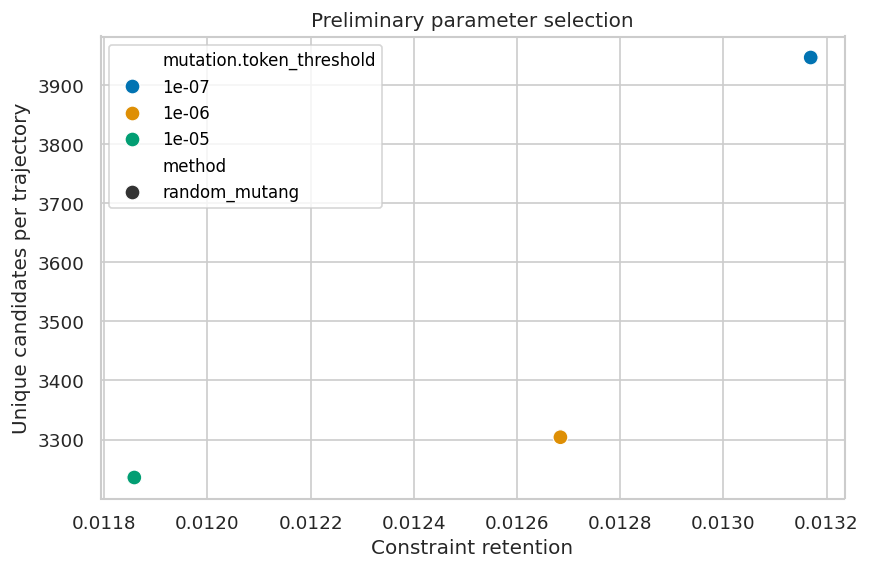

In [9]:
parameter_result = analysis.locality.parameter_selection()
display(parameter_result.data)
display(pd.Series(parameter_result.metadata, name='value'))
analysis.visualize.locality.parameter_selection(parameter_result)

## Cache status

Cache keys include input file sizes and modification times, so regenerated tracker tables invalidate stale numerical results.

In [10]:
print(f'Analysis cache: {reader.metrics.path}')
display(reader.cached_analyses())

Analysis cache: /home/maxi7524/repositories/pep-compass/results/locality_test/.pep_compass_analysis.sqlite


,analysis_name,analysis_version,selection_hash,parameters_hash,selection_json,parameters_json,metadata_json
0,locality.latent_locality,4,e0a2a71bc238b725c2a1cdf0b67bb5f5d1b96056cdc560...,d4644f2cb0e4068f00f1f6f8cd1cb210d1f672c0f2add8...,"{""input_files"": [{""mtime_ns"": 1785412594870245...","{""candidate_sample_size"": 50000, ""candidate_sc...","{""analysis"": ""latent_locality"", ""candidate_pop..."
1,locality.mutang_selectivity,4,e0a2a71bc238b725c2a1cdf0b67bb5f5d1b96056cdc560...,44136fa355b3678a1146ad16f7e8649e94fb4fc21fe77e...,"{""input_files"": [{""mtime_ns"": 1785412594870245...",{},"{""analysis"": ""mutang_selectivity"", ""correlatio..."
2,locality.parameter_selection,4,e0a2a71bc238b725c2a1cdf0b67bb5f5d1b96056cdc560...,44136fa355b3678a1146ad16f7e8649e94fb4fc21fe77e...,"{""input_files"": [{""mtime_ns"": 1785412594870245...",{},"{""analysis"": ""parameter_selection"", ""elapsed_s..."
3,locality.step_saturation,4,e0a2a71bc238b725c2a1cdf0b67bb5f5d1b96056cdc560...,b9213e5518d9f7ab0096a1a3b31ba98cc0961ee1b0d679...,"{""input_files"": [{""mtime_ns"": 1785412594870245...","{""accepted_only"": false, ""chunk_size"": 100000,...","{""accepted_only"": false, ""analysis"": ""step_sat..."
4,locality.trajectory_saturation,4,e0a2a71bc238b725c2a1cdf0b67bb5f5d1b96056cdc560...,7176155e2788b6a27862ff68a46ce2b315a82865b63d1f...,"{""input_files"": [{""mtime_ns"": 1785412594870245...","{""accepted_only"": false, ""chunk_size"": 100000,...","{""accepted_only"": false, ""analysis"": ""trajecto..."
